Please include USDA_MASTER_CORN.csv, NASA_MASTER_WEATHER.csv, TEXAS_COUNTY_SOIL_TRUE.csv before running, the code to generate the csv files weren't included due to the API blocking overusage. Since the API was already used to pull the original data to validate the model the API might get blocked if we try to pull twice.

=== [PHASE 1] INITIALIZING SECURE MULTI-SOURCE PIPELINE ===
[DATA] Dropped 0 records due to unmapped soil zones.
[SUCCESS] Final Matrix: 1811 biologically complete rows ready for modeling.

=== [PHASE 2] ENGINEERING NON-LINEAR WEATHER PROXIES ===

=== [PHASE 3] EXECUTING WALK-FORWARD VALIDATION (ROLLING ORIGIN) ===

[PIPELINE] Time-stepping to Year 2018...
  -> [RESULT] 2018 Accuracy | R-Squared: 0.7546 | RMSE: 19.35 bu/ac

[PIPELINE] Time-stepping to Year 2019...
  -> [RESULT] 2019 Accuracy | R-Squared: 0.3056 | RMSE: 28.73 bu/ac

[PIPELINE] Time-stepping to Year 2020...
  -> [RESULT] 2020 Accuracy | R-Squared: 0.7378 | RMSE: 21.15 bu/ac

[PIPELINE] Time-stepping to Year 2021...
  -> [RESULT] 2021 Accuracy | R-Squared: 0.8076 | RMSE: 21.46 bu/ac

[PIPELINE] Time-stepping to Year 2022...
  -> [RESULT] 2022 Accuracy | R-Squared: 0.6584 | RMSE: 23.45 bu/ac

[PIPELINE] Time-stepping to Year 2023...
  -> [RESULT] 2023 Accuracy | R-Squared: 0.3387 | RMSE: 21.38 bu/ac

[PIPELINE] Time-steppi

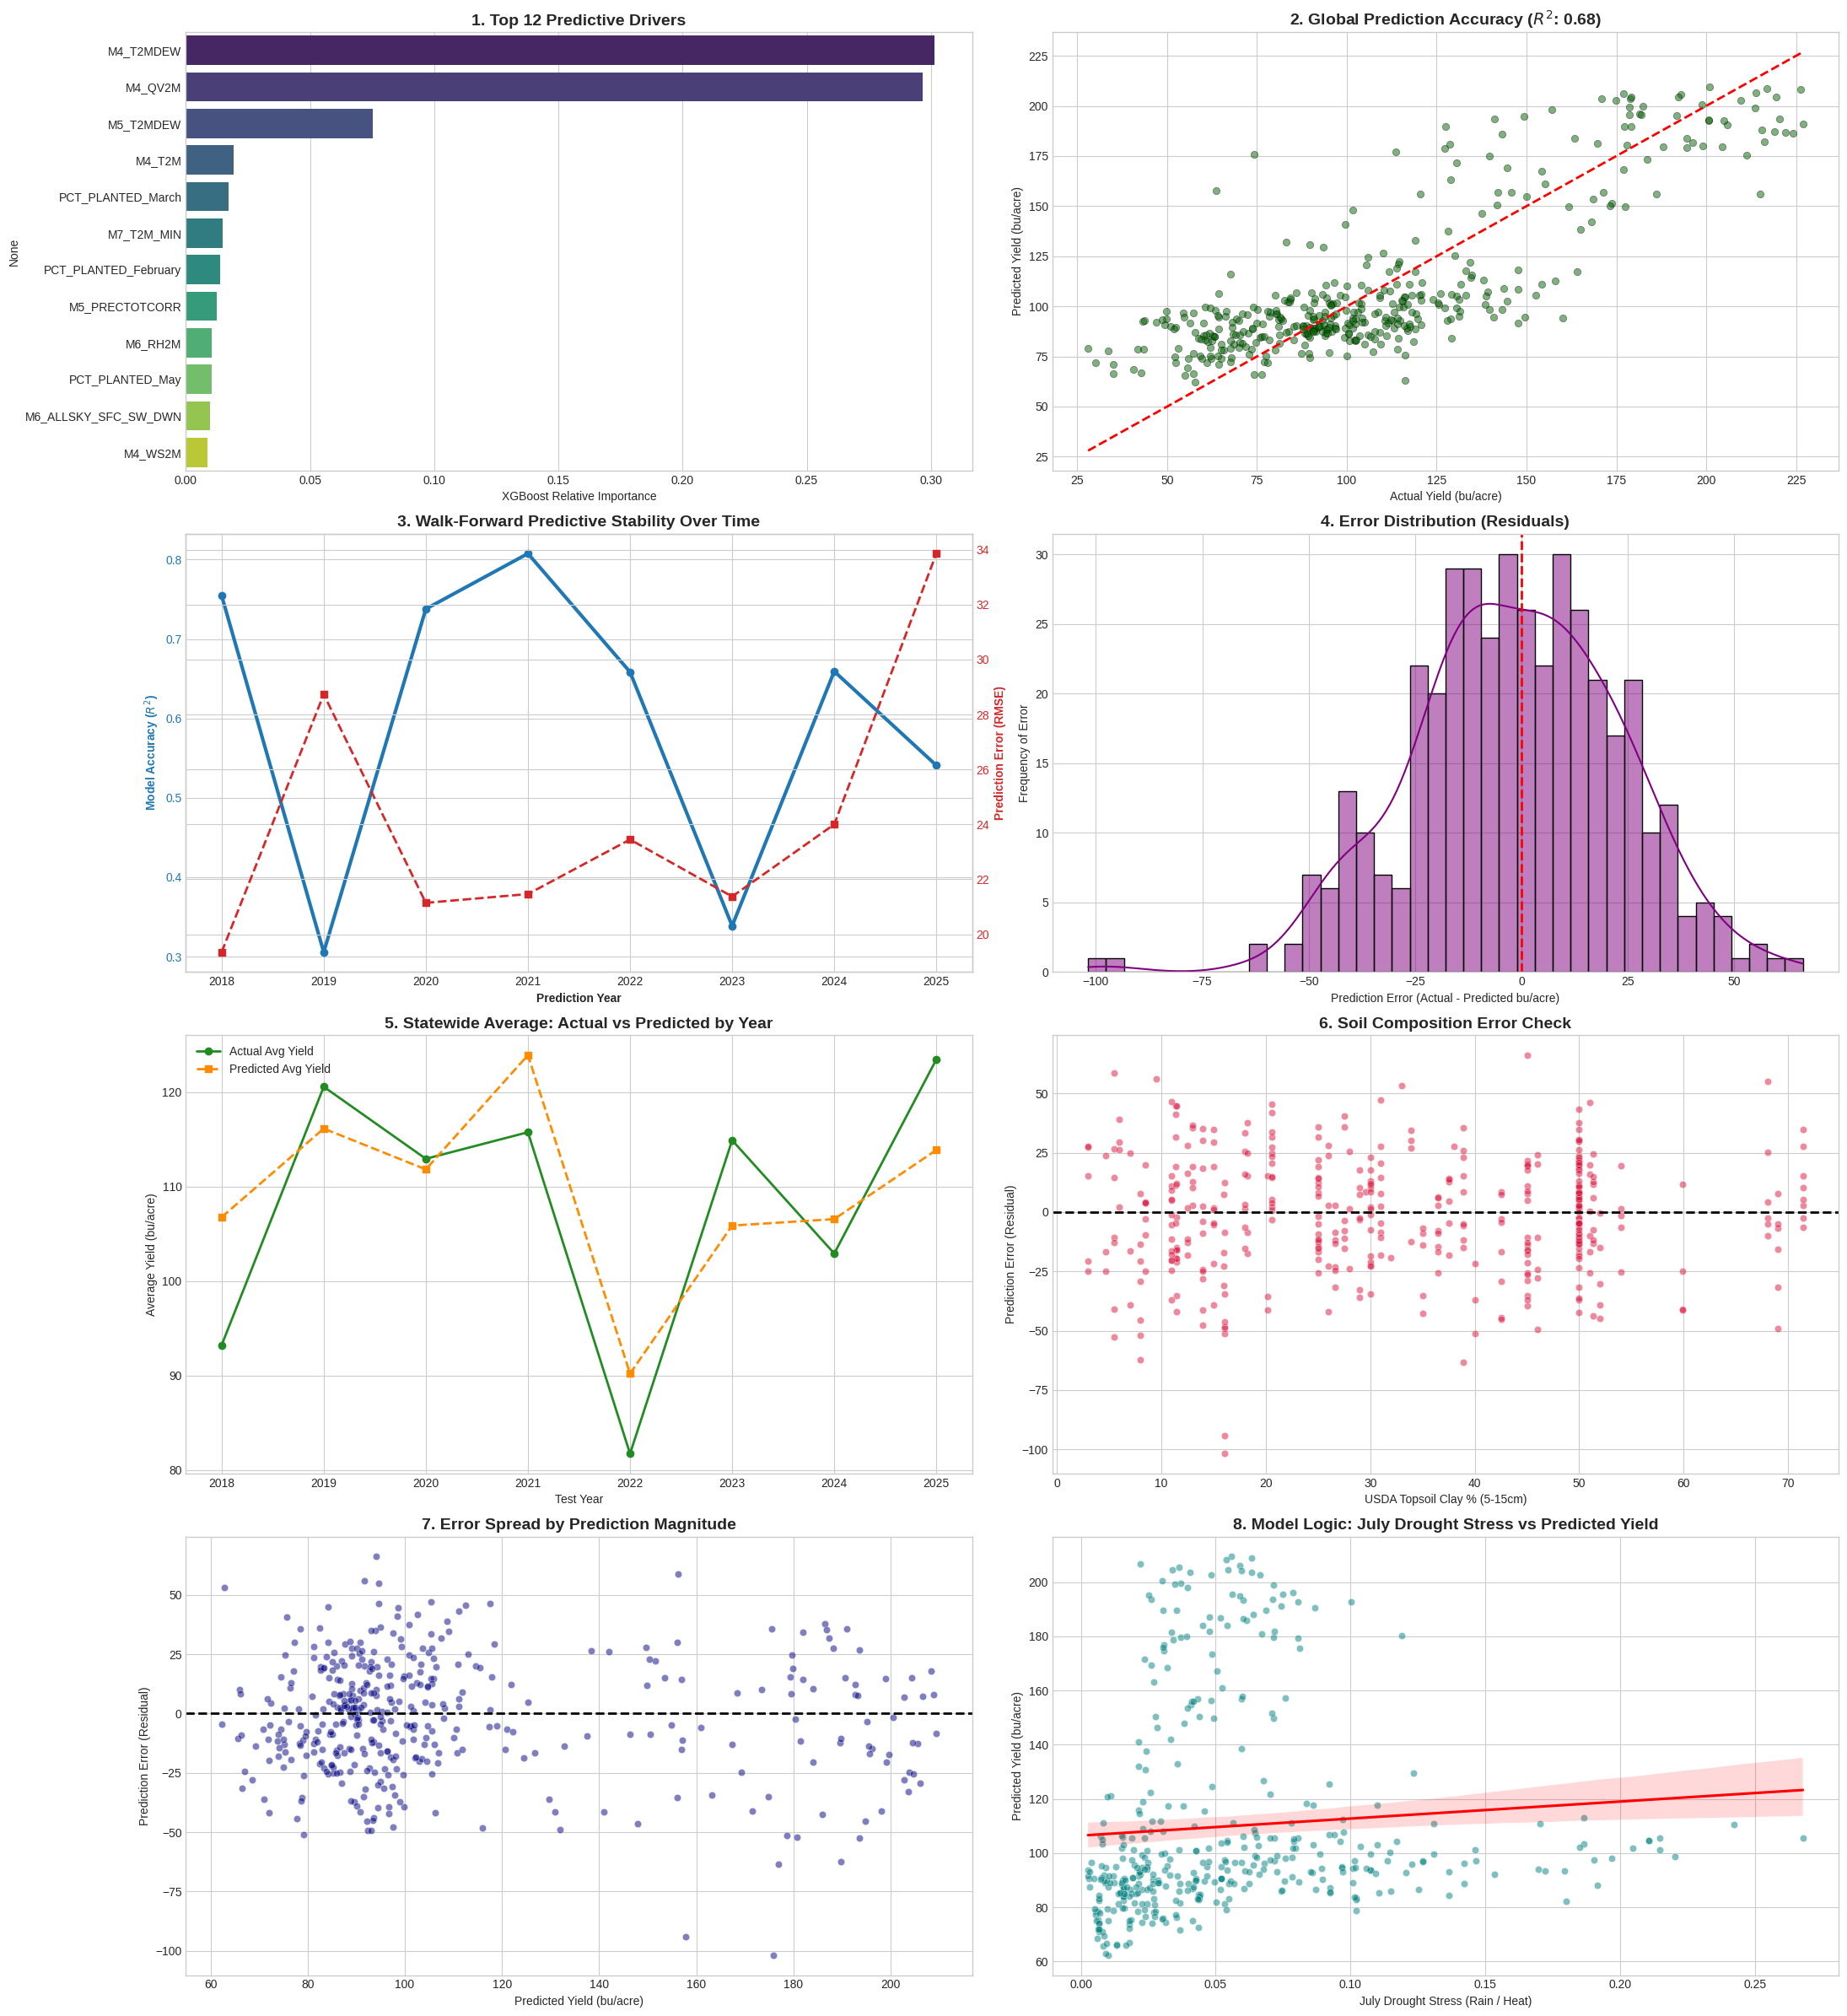

[SYSTEM] Walk-Forward pipeline complete. Advanced 8-Panel dashboard saved as 'Final_Master_Corn_Advanced_Dashboard.png'.


In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# PHASE 1: SECURE DATA INGESTION & MERGING
# ==========================================================
print("=== [PHASE 1] INITIALIZING SECURE MULTI-SOURCE PIPELINE ===")

try:
    df_usda = pd.read_csv("USDA_MASTER_CORN.csv")
    df_nasa = pd.read_csv("NASA_MASTER_WEATHER.csv")
    df_soil = pd.read_csv("TEXAS_COUNTY_SOIL_TRUE.csv")
except FileNotFoundError as e:
    print(f"\n[FATAL ERROR] Missing file: {e}")
    print("Please ensure USDA_MASTER_CORN.csv, NASA_MASTER_WEATHER.csv, and TEXAS_COUNTY_SOIL_TRUE.csv are uploaded.")
    raise

# Clean strings for perfect merging
df_usda['County'] = df_usda['County'].astype(str).str.strip().str.upper()
df_nasa['County'] = df_nasa['County'].astype(str).str.strip().str.upper()
df_soil['County'] = df_soil['County'].astype(str).str.strip().str.upper()

# Drop the empty soil columns from the original NASA pull so they don't clash
df_nasa = df_nasa.drop(columns=['Soil_pH', 'Soil_Clay_Pct', 'Soil_Organic_Carbon'], errors='ignore')

# Sequential Merge
df_temp = pd.merge(df_usda, df_nasa, on=['Year', 'County'], how='inner')
df = pd.merge(df_temp, df_soil, on='County', how='inner')

# Protection: Drop counties that hit water/urban areas (Missing Soil)
initial_len = len(df)
df = df.dropna(subset=['Soil_Clay_Pct', 'Soil_pH'])
print(f"[DATA] Dropped {initial_len - len(df)} records due to unmapped soil zones.")
print(f"[SUCCESS] Final Matrix: {len(df)} biologically complete rows ready for modeling.")

# ==========================================================
# PHASE 2: HONEST BIO-CLIMATIC ENGINEERING (CORN)
# ==========================================================
print("\n=== [PHASE 2] ENGINEERING NON-LINEAR WEATHER PROXIES ===")

# 1. July Drought Stress Proxy
df['JUL_Drought_Stress'] = df['M7_PRECTOTCORR'] / (df['M7_T2M_MAX'] + 1)

# 2. May Radiation Efficiency
df['MAY_Rad_Eff'] = df['M5_ALLSKY_SFC_SW_DWN'] / (df['M5_T2M_MAX'] + 1)

# 3. June Vapor Pressure Deficit Proxy
df['JUN_VPD_Proxy'] = df['M6_T2M_MAX'] - df['M6_T2MDEW']

# Force the data into numeric, keep Year and County attached for the split
df = df.apply(pd.to_numeric, errors='ignore')
TARGET = 'Yield_Bu_Acre'

# ==========================================================
# PHASE 3: THE CUMULATIVE WALK-FORWARD ARCHITECTURE
# ==========================================================
print("\n=== [PHASE 3] EXECUTING WALK-FORWARD VALIDATION (ROLLING ORIGIN) ===")

all_years = sorted(df['Year'].unique())
START_TEST_YEAR = 2018

yearly_metrics = []
cumulative_y_true = []
cumulative_y_pred = []

# Added arrays to store data specifically for the new graphs
cumulative_years = []
cumulative_clay = []
cumulative_july_drought = []

for target_year in all_years:
    if target_year < START_TEST_YEAR:
        continue

    print(f"\n[PIPELINE] Time-stepping to Year {target_year}...")

    # 1. Train on EVERYTHING strictly before the target year
    train_df = df[df['Year'] < target_year]
    # 2. Test ONLY on the target year (The Future)
    test_df = df[df['Year'] == target_year]

    if len(test_df) == 0:
        continue

    X_train = train_df.drop(columns=['Year', 'County', TARGET])
    y_train = train_df[TARGET]

    X_test = test_df.drop(columns=['Year', 'County', TARGET])
    y_test = test_df[TARGET]

    # 3. Compile the brain for this specific iteration
    model = xgb.XGBRegressor(
        n_estimators=350,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    # 4. Train and Predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 5. Evaluate this specific year
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    yearly_metrics.append({'Year': target_year, 'R2': r2, 'RMSE': rmse})
    cumulative_y_true.extend(y_test)
    cumulative_y_pred.extend(y_pred)

    # Store data for the new visual dashboard
    cumulative_years.extend([target_year] * len(y_test))
    cumulative_clay.extend(test_df['Soil_Clay_Pct'].values)
    cumulative_july_drought.extend(test_df['JUL_Drought_Stress'].values)

    print(f"  -> [RESULT] {target_year} Accuracy | R-Squared: {r2:.4f} | RMSE: {rmse:.2f} bu/ac")

# ==========================================================
# PHASE 4: EXTENDED EVALUATION & 8-PANEL DASHBOARD
# ==========================================================
print("\n" + "X"*55)
print("     CUMULATIVE WALK-FORWARD EVALUATION REPORT (CORN)")
print("X"*55)

total_r2 = r2_score(cumulative_y_true, cumulative_y_pred)
total_rmse = np.sqrt(mean_squared_error(cumulative_y_true, cumulative_y_pred))
total_mae = mean_absolute_error(cumulative_y_true, cumulative_y_pred)

print(f"Cumulative Walk-Forward R-Squared : {total_r2:.4f}")
print(f"Cumulative Walk-Forward RMSE      : {total_rmse:.2f} bu/acre")
print(f"Cumulative Walk-Forward MAE       : {total_mae:.2f} bu/acre")
print("X"*55 + "\n")

print("[RENDERING] Generating Advanced 8-Panel Visual Dashboard...")

# Prepare a results dataframe for the new visual plots
res_df = pd.DataFrame({
    'Year': cumulative_years,
    'True_Yield': cumulative_y_true,
    'Pred_Yield': cumulative_y_pred,
    'Residual': np.array(cumulative_y_true) - np.array(cumulative_y_pred),
    'Soil_Clay_Pct': cumulative_clay,
    'JUL_Drought_Stress': cumulative_july_drought
})

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(22, 24))

# --- Graph 1: Feature Importance ---
ax1 = fig.add_subplot(4, 2, 1)
feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_features = feat_importances.nlargest(12)
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', ax=ax1)
ax1.set_title('1. Top 12 Predictive Drivers', fontsize=14, fontweight='bold')
ax1.set_xlabel('XGBoost Relative Importance')

# --- Graph 2: Global Actual vs Predicted ---
ax2 = fig.add_subplot(4, 2, 2)
sns.scatterplot(x='True_Yield', y='Pred_Yield', data=res_df, alpha=0.5, color='darkgreen', edgecolor='black', ax=ax2)
min_val = min(res_df['True_Yield'].min(), res_df['Pred_Yield'].min())
max_val = max(res_df['True_Yield'].max(), res_df['Pred_Yield'].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
ax2.set_title(f'2. Global Prediction Accuracy ($R^2$: {total_r2:.2f})', fontsize=14, fontweight='bold')
ax2.set_xlabel('Actual Yield (bu/acre)')
ax2.set_ylabel('Predicted Yield (bu/acre)')

# --- Graph 3: Walk-Forward Stability Trend ---
ax3 = fig.add_subplot(4, 2, 3)
metrics_df = pd.DataFrame(yearly_metrics)
color1 = 'tab:blue'
ax3.set_xlabel('Prediction Year', fontweight='bold')
ax3.set_ylabel('Model Accuracy ($R^2$)', color=color1, fontweight='bold')
ax3.plot(metrics_df['Year'], metrics_df['R2'], marker='o', linewidth=3, color=color1)
ax3.tick_params(axis='y', labelcolor=color1)
ax3.set_xticks(metrics_df['Year'])
ax3_twin = ax3.twinx()
color2 = 'tab:red'
ax3_twin.set_ylabel('Prediction Error (RMSE)', color=color2, fontweight='bold')
ax3_twin.plot(metrics_df['Year'], metrics_df['RMSE'], marker='s', linestyle='--', linewidth=2, color=color2)
ax3_twin.tick_params(axis='y', labelcolor=color2)
ax3.set_title('3. Walk-Forward Predictive Stability Over Time', fontsize=14, fontweight='bold')

# --- Graph 4: Residual Error Distribution ---
ax4 = fig.add_subplot(4, 2, 4)
sns.histplot(res_df['Residual'], kde=True, color='purple', bins=40, ax=ax4)
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax4.set_title('4. Error Distribution (Residuals)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Prediction Error (Actual - Predicted bu/acre)')
ax4.set_ylabel('Frequency of Error')

# --- Graph 5: Average Statewide Yield over Time ---
ax5 = fig.add_subplot(4, 2, 5)
yearly_avg = res_df.groupby('Year')[['True_Yield', 'Pred_Yield']].mean().reset_index()
ax5.plot(yearly_avg['Year'], yearly_avg['True_Yield'], label='Actual Avg Yield', marker='o', color='forestgreen', linewidth=2)
ax5.plot(yearly_avg['Year'], yearly_avg['Pred_Yield'], label='Predicted Avg Yield', marker='s', color='darkorange', linewidth=2, linestyle='--')
ax5.set_title('5. Statewide Average: Actual vs Predicted by Year', fontsize=14, fontweight='bold')
ax5.set_xlabel('Test Year')
ax5.set_ylabel('Average Yield (bu/acre)')
ax5.set_xticks(yearly_avg['Year'])
ax5.legend()

# --- Graph 6: Soil Clay % vs. Model Error ---
ax6 = fig.add_subplot(4, 2, 6)
sns.scatterplot(x='Soil_Clay_Pct', y='Residual', data=res_df, alpha=0.5, color='crimson', ax=ax6)
ax6.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax6.set_title('6. Soil Composition Error Check', fontsize=14, fontweight='bold')
ax6.set_xlabel('USDA Topsoil Clay % (5-15cm)')
ax6.set_ylabel('Prediction Error (Residual)')

# --- Graph 7: Heteroscedasticity Check ---
ax7 = fig.add_subplot(4, 2, 7)
sns.scatterplot(x='Pred_Yield', y='Residual', data=res_df, alpha=0.5, color='navy', ax=ax7)
ax7.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax7.set_title('7. Error Spread by Prediction Magnitude', fontsize=14, fontweight='bold')
ax7.set_xlabel('Predicted Yield (bu/acre)')
ax7.set_ylabel('Prediction Error (Residual)')

# --- Graph 8: Bio-Climatic Logic Check ---
ax8 = fig.add_subplot(4, 2, 8)
sns.scatterplot(x='JUL_Drought_Stress', y='Pred_Yield', data=res_df, alpha=0.5, color='teal', ax=ax8)
sns.regplot(x='JUL_Drought_Stress', y='Pred_Yield', data=res_df, scatter=False, color='red', ax=ax8)
ax8.set_title('8. Model Logic: July Drought Stress vs Predicted Yield', fontsize=14, fontweight='bold')
ax8.set_xlabel('July Drought Stress (Rain / Heat)')
ax8.set_ylabel('Predicted Yield (bu/acre)')

plt.tight_layout()
plt.savefig('Final_Master_Corn_Advanced_Dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("[SYSTEM] Walk-Forward pipeline complete. Advanced 8-Panel dashboard saved as 'Final_Master_Corn_Advanced_Dashboard.png'.")

Please Include

Please Include TEXAS_COUNTY_SOIL_TRUE.csv, USDA_COTTON_DRYLAND_COMPLETE.csv, USDA_COTTON_IRRIGATED.csv, NASA_WEATHER.csv


=== [PHASE 1] INITIALIZING SECURE MULTI-SOURCE PIPELINE (COTTON) ===
[DATA] Dropped 0 records due to unmapped soil zones.
[SUCCESS] Final Matrix: 1380 biologically complete rows ready for modeling.

=== [PHASE 2] ENGINEERING NON-LINEAR WEATHER PROXIES ===

=== [PHASE 3] EXECUTING WALK-FORWARD VALIDATION (ROLLING ORIGIN) ===

[PIPELINE] Time-stepping to Year 2018...
  -> [RESULT] 2018 Accuracy | R-Squared: 0.5479 | RMSE: 235.20 lbs/ac

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
     CUMULATIVE WALK-FORWARD EVALUATION REPORT (COTTON)
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
Cumulative Walk-Forward R-Squared : 0.5479
Cumulative Walk-Forward RMSE      : 235.20 lbs/acre
Cumulative Walk-Forward MAE       : 200.13 lbs/acre
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

[RENDERING] Generating Advanced 8-Panel Visual Dashboard...


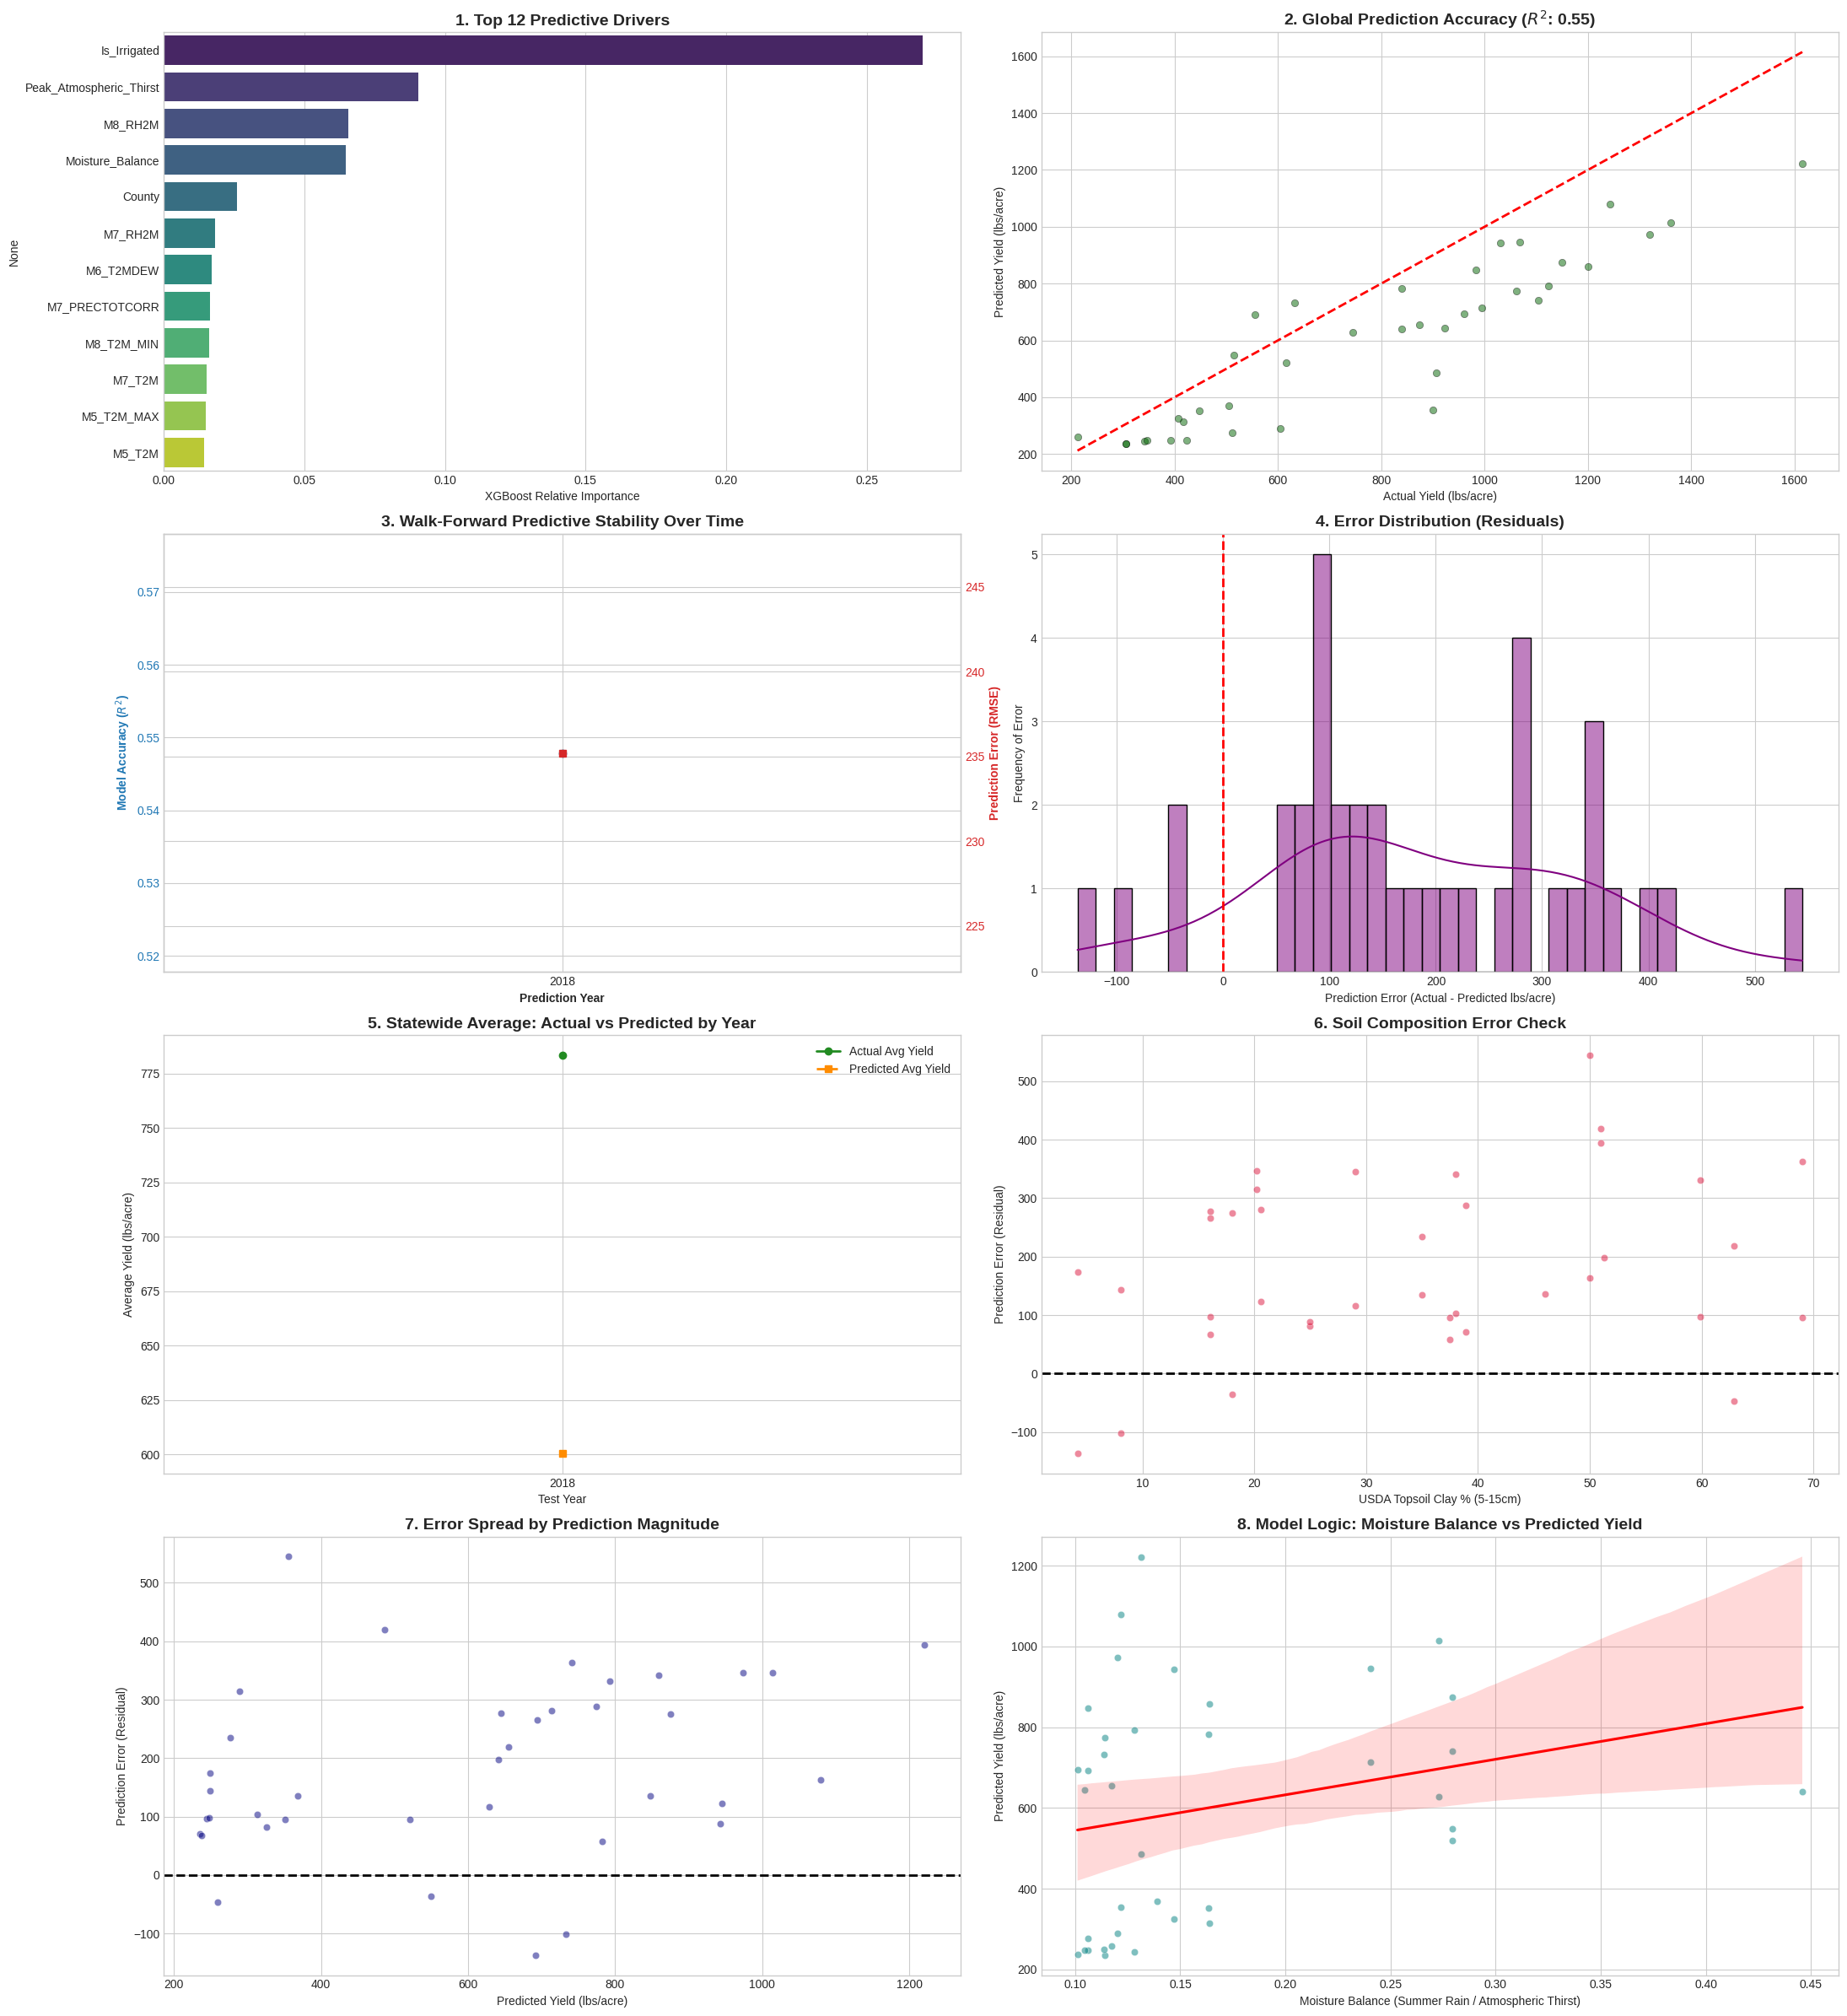

[SYSTEM] Walk-Forward pipeline complete. Advanced 8-Panel dashboard saved as 'Final_Cotton_Advanced_Dashboard.png'.


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# PHASE 1: SECURE DATA INGESTION & MERGING
# ==========================================================
print("=== [PHASE 1] INITIALIZING SECURE MULTI-SOURCE PIPELINE (COTTON) ===")

try:
    # 1. Load the Split Cotton Files and Combine Them with a Tag!
    df_dry = pd.read_csv("USDA_COTTON_DRYLAND_COMPLETE.csv")
    df_dry['Is_Irrigated'] = 0 # Tag as Dryland

    df_irr = pd.read_csv("USDA_COTTON_IRRIGATED_COMPLETE.csv")
    df_irr['Is_Irrigated'] = 1 # Tag as Irrigated

    # Concatenate to create the true Master Cotton Dataset
    df_usda = pd.concat([df_dry, df_irr], ignore_index=True)

    # 2. Load Weather and Soil
    df_nasa = pd.read_csv("NASA_COTTON_WEATHER.csv")
    df_soil = pd.read_csv("TEXAS_COUNTY_SOIL_TRUE.csv")
except FileNotFoundError as e:
    print(f"\n[FATAL ERROR] Missing file: {e}")
    print("Ensure DRYLAND, IRRIGATED, WEATHER, and SOIL CSV files are uploaded.")
    raise

# Clean strings for perfect merging
for df_temp in [df_usda, df_nasa, df_soil]:
    if 'County' in df_temp.columns:
        df_temp['County'] = df_temp['County'].astype(str).str.strip().str.upper()

# Drop broken soil columns from NASA pull so they don't clash
df_nasa = df_nasa.drop(columns=['Soil_pH', 'Soil_Clay_Pct', 'Soil_Organic_Carbon'], errors='ignore')

# Master Merge
df_temp = pd.merge(df_usda, df_nasa, on=['Year', 'County'], how='inner')
df = pd.merge(df_temp, df_soil, on='County', how='inner')

# Protection: Drop counties that hit water/urban areas (Missing Soil)
initial_len = len(df)
df = df.dropna(subset=['Soil_Clay_Pct', 'Soil_pH'])
print(f"[DATA] Dropped {initial_len - len(df)} records due to unmapped soil zones.")
print(f"[SUCCESS] Final Matrix: {len(df)} biologically complete rows ready for modeling.")

# ==========================================================
# PHASE 2: HONEST BIO-CLIMATIC ENGINEERING (COTTON)
# ==========================================================
print("\n=== [PHASE 2] ENGINEERING NON-LINEAR WEATHER PROXIES ===")

# The Proven Killers & Saviors for Cotton
df['Summer_Heat_Load'] = df['M6_T2M_MAX'] + df['M7_T2M_MAX'] + df['M8_T2M_MAX']
df['Summer_Rain_Total'] = df['M5_PRECTOTCORR'] + df['M6_PRECTOTCORR'] + df['M7_PRECTOTCORR'] + df['M8_PRECTOTCORR']
df['Peak_Atmospheric_Thirst'] = (df['M7_T2M_MAX'] - df['M7_T2MDEW']) + (df['M8_T2M_MAX'] - df['M8_T2MDEW'])
df['Moisture_Balance'] = df['Summer_Rain_Total'] / (df['Peak_Atmospheric_Thirst'] + 1)
df['HARVEST_Rain_Penalty'] = df['M9_PRECTOTCORR'] + df['M10_PRECTOTCORR']

# Force the data into numeric
df = df.apply(pd.to_numeric, errors='ignore')
TARGET = 'Yield_Lbs_Acre'

# ==========================================================
# PHASE 3: THE CUMULATIVE WALK-FORWARD ARCHITECTURE
# ==========================================================
print("\n=== [PHASE 3] EXECUTING WALK-FORWARD VALIDATION (ROLLING ORIGIN) ===")

all_years = sorted(df['Year'].unique())
START_TEST_YEAR = 2018

yearly_metrics = []
cumulative_y_true = []
cumulative_y_pred = []

# Arrays for the 8-Panel Dashboard
cumulative_years = []
cumulative_clay = []
cumulative_moisture = []

# Convert County to categorical for native XGBoost handling
df['County'] = df['County'].astype('category')

# Drop Target Leaks (Planting Data)
cols_to_drop = ['Year', TARGET]
for col in df.columns:
    if 'PCT_PLANTED' in col:
        cols_to_drop.append(col)

for target_year in all_years:
    if target_year < START_TEST_YEAR:
        continue

    print(f"\n[PIPELINE] Time-stepping to Year {target_year}...")

    train_df = df[df['Year'] < target_year].copy()
    test_df = df[df['Year'] == target_year].copy()

    if len(test_df) == 0:
        continue

    X_train = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
    y_train = train_df[TARGET]

    X_test = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])
    y_test = test_df[TARGET]

    # Model tuned with Categorical support
    model = xgb.XGBRegressor(
        enable_categorical=True,
        tree_method='hist',
        n_estimators=350,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    yearly_metrics.append({'Year': target_year, 'R2': r2, 'RMSE': rmse})
    cumulative_y_true.extend(y_test)
    cumulative_y_pred.extend(y_pred)

    # Store data for visual dashboard
    cumulative_years.extend([target_year] * len(y_test))
    cumulative_clay.extend(test_df['Soil_Clay_Pct'].values)
    cumulative_moisture.extend(test_df['Moisture_Balance'].values)

    print(f"  -> [RESULT] {target_year} Accuracy | R-Squared: {r2:.4f} | RMSE: {rmse:.2f} lbs/ac")

# ==========================================================
# PHASE 4: EXTENDED EVALUATION & 8-PANEL DASHBOARD
# ==========================================================
print("\n" + "X"*55)
print("     CUMULATIVE WALK-FORWARD EVALUATION REPORT (COTTON)")
print("X"*55)

total_r2 = r2_score(cumulative_y_true, cumulative_y_pred)
total_rmse = np.sqrt(mean_squared_error(cumulative_y_true, cumulative_y_pred))
total_mae = mean_absolute_error(cumulative_y_true, cumulative_y_pred)

print(f"Cumulative Walk-Forward R-Squared : {total_r2:.4f}")
print(f"Cumulative Walk-Forward RMSE      : {total_rmse:.2f} lbs/acre")
print(f"Cumulative Walk-Forward MAE       : {total_mae:.2f} lbs/acre")
print("X"*55 + "\n")

print("[RENDERING] Generating Advanced 8-Panel Visual Dashboard...")

# Prepare a results dataframe for the new visual plots
res_df = pd.DataFrame({
    'Year': cumulative_years,
    'True_Yield': cumulative_y_true,
    'Pred_Yield': cumulative_y_pred,
    'Residual': np.array(cumulative_y_true) - np.array(cumulative_y_pred),
    'Soil_Clay_Pct': cumulative_clay,
    'Moisture_Balance': cumulative_moisture
})

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(22, 24))

# --- Graph 1: Feature Importance ---
ax1 = fig.add_subplot(4, 2, 1)
feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_features = feat_importances.nlargest(12)
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', ax=ax1)
ax1.set_title('1. Top 12 Predictive Drivers', fontsize=14, fontweight='bold')
ax1.set_xlabel('XGBoost Relative Importance')

# --- Graph 2: Global Actual vs Predicted ---
ax2 = fig.add_subplot(4, 2, 2)
sns.scatterplot(x='True_Yield', y='Pred_Yield', data=res_df, alpha=0.5, color='darkgreen', edgecolor='black', ax=ax2)
min_val = min(res_df['True_Yield'].min(), res_df['Pred_Yield'].min())
max_val = max(res_df['True_Yield'].max(), res_df['Pred_Yield'].max())
ax2.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
ax2.set_title(f'2. Global Prediction Accuracy ($R^2$: {total_r2:.2f})', fontsize=14, fontweight='bold')
ax2.set_xlabel('Actual Yield (lbs/acre)')
ax2.set_ylabel('Predicted Yield (lbs/acre)')

# --- Graph 3: Walk-Forward Stability Trend ---
ax3 = fig.add_subplot(4, 2, 3)
metrics_df = pd.DataFrame(yearly_metrics)
color1 = 'tab:blue'
ax3.set_xlabel('Prediction Year', fontweight='bold')
ax3.set_ylabel('Model Accuracy ($R^2$)', color=color1, fontweight='bold')
ax3.plot(metrics_df['Year'], metrics_df['R2'], marker='o', linewidth=3, color=color1)
ax3.tick_params(axis='y', labelcolor=color1)
ax3.set_xticks(metrics_df['Year'])
ax3_twin = ax3.twinx()
color2 = 'tab:red'
ax3_twin.set_ylabel('Prediction Error (RMSE)', color=color2, fontweight='bold')
ax3_twin.plot(metrics_df['Year'], metrics_df['RMSE'], marker='s', linestyle='--', linewidth=2, color=color2)
ax3_twin.tick_params(axis='y', labelcolor=color2)
ax3.set_title('3. Walk-Forward Predictive Stability Over Time', fontsize=14, fontweight='bold')

# --- Graph 4: Residual Error Distribution ---
ax4 = fig.add_subplot(4, 2, 4)
sns.histplot(res_df['Residual'], kde=True, color='purple', bins=40, ax=ax4)
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax4.set_title('4. Error Distribution (Residuals)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Prediction Error (Actual - Predicted lbs/acre)')
ax4.set_ylabel('Frequency of Error')

# --- Graph 5: Average Statewide Yield over Time ---
ax5 = fig.add_subplot(4, 2, 5)
yearly_avg = res_df.groupby('Year')[['True_Yield', 'Pred_Yield']].mean().reset_index()
ax5.plot(yearly_avg['Year'], yearly_avg['True_Yield'], label='Actual Avg Yield', marker='o', color='forestgreen', linewidth=2)
ax5.plot(yearly_avg['Year'], yearly_avg['Pred_Yield'], label='Predicted Avg Yield', marker='s', color='darkorange', linewidth=2, linestyle='--')
ax5.set_title('5. Statewide Average: Actual vs Predicted by Year', fontsize=14, fontweight='bold')
ax5.set_xlabel('Test Year')
ax5.set_ylabel('Average Yield (lbs/acre)')
ax5.set_xticks(yearly_avg['Year'])
ax5.legend()

# --- Graph 6: Soil Clay % vs. Model Error ---
ax6 = fig.add_subplot(4, 2, 6)
sns.scatterplot(x='Soil_Clay_Pct', y='Residual', data=res_df, alpha=0.5, color='crimson', ax=ax6)
ax6.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax6.set_title('6. Soil Composition Error Check', fontsize=14, fontweight='bold')
ax6.set_xlabel('USDA Topsoil Clay % (5-15cm)')
ax6.set_ylabel('Prediction Error (Residual)')

# --- Graph 7: Heteroscedasticity Check ---
ax7 = fig.add_subplot(4, 2, 7)
sns.scatterplot(x='Pred_Yield', y='Residual', data=res_df, alpha=0.5, color='navy', ax=ax7)
ax7.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax7.set_title('7. Error Spread by Prediction Magnitude', fontsize=14, fontweight='bold')
ax7.set_xlabel('Predicted Yield (lbs/acre)')
ax7.set_ylabel('Prediction Error (Residual)')

# --- Graph 8: Bio-Climatic Logic Check ---
ax8 = fig.add_subplot(4, 2, 8)
sns.scatterplot(x='Moisture_Balance', y='Pred_Yield', data=res_df, alpha=0.5, color='teal', ax=ax8)
sns.regplot(x='Moisture_Balance', y='Pred_Yield', data=res_df, scatter=False, color='red', ax=ax8)
ax8.set_title('8. Model Logic: Moisture Balance vs Predicted Yield', fontsize=14, fontweight='bold')
ax8.set_xlabel('Moisture Balance (Summer Rain / Atmospheric Thirst)')
ax8.set_ylabel('Predicted Yield (lbs/acre)')

plt.tight_layout()
plt.savefig('Final_Cotton_Advanced_Dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("[SYSTEM] Walk-Forward pipeline complete. Advanced 8-Panel dashboard saved as 'Final_Cotton_Advanced_Dashboard.png'.")